<a href="https://colab.research.google.com/github/www-fidezDAE/fidez.RDS/blob/main/USScompetition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive Mounting and Data Uploading

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Step 1: Upload file manually
from google.colab import files
import pandas as pd

uploaded = files.upload()  # This lets you pick file from your PC
file_path = list(uploaded.keys())[0]  # Automatically use uploaded filename

# Step 2: Read dataset
# Use pd.read_excel for .xlsx files
data = pd.read_excel(file_path)
print("5G_Datasets (first 5 rows):")
print(data.head())

Saving UCrime_Dataset.xlsx to UCrime_Dataset (3).xlsx
5G_Datasets (first 5 rows):
           Region  Year  Total_Crime_Cases  Population  Crime_Rate_per_100k  \
0           Rwizi  2019            13527.0    42999637            31.458405   
1       KMP North  2019            11777.0    42999637            27.388603   
2     North Kyoga  2019            13343.0    42999637            31.030495   
3       KMP South  2019            12559.0    42999637            29.207223   
4  Greater Masaka  2019            11789.0    42999637            27.416511   

                 Crime_Category  Urbanization_Rate  Unemployment_Rate  \
0                         Theft              4.417               3.06   
1                       Assault              4.617               3.06   
2             Domestic Violence              4.826               3.06   
3  Economic & Corruption Crimes              5.045               3.06   
4                     Robberies              5.273               3.06   

   P

Required Installations

In [ ]:
!pip install pandas numpy matplotlib seaborn plotly geopandas scikit-learn statsmodels folium pmdarima

Objective 1: Descriptive & Temporal Trend Analysis (2019–2024)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Region               180 non-null    object 
 1   Year                 180 non-null    int64  
 2   Total_Crime_Cases    180 non-null    float64
 3   Population           180 non-null    int64  
 4   Crime_Rate_per_100k  180 non-null    float64
 5   Crime_Category       180 non-null    object 
 6   Urbanization_Rate    180 non-null    float64
 7   Unemployment_Rate    180 non-null    float64
 8   Poverty_Index        180 non-null    float64
dtypes: float64(5), int64(2), object(2)
memory usage: 12.8+ KB
Data Preview:


,Region,Year,Total_Crime_Cases,Population,Crime_Rate_per_100k,Crime_Category,Urbanization_Rate,Unemployment_Rate,Poverty_Index
0,Rwizi,2019,13527.0,42999637,31.458405,Theft,4.417,3.06,18.0
1,KMP North,2019,11777.0,42999637,27.388603,Assault,4.617,3.06,18.0
2,North Kyoga,2019,13343.0,42999637,31.030495,Domestic Violence,4.826,3.06,18.0
3,KMP South,2019,12559.0,42999637,29.207223,Economic & Corruption Crimes,5.045,3.06,18.7
4,Greater Masaka,2019,11789.0,42999637,27.416511,Robberies,5.273,3.06,18.5



Descriptive Statistics:


,Year,Total_Crime_Cases,Population,Crime_Rate_per_100k,Urbanization_Rate,Unemployment_Rate,Poverty_Index
count,180.000000,180.000000,1.800000e+02,180.000000,180.000000,180.000000,180.000000
mean,2021.500000,7166.644828,4.655869e+07,15.411318,13.660156,3.154500,31.025000
std,1.712589,3775.964354,2.401795e+06,8.008875,6.828134,0.364071,15.767727
min,2019.000000,537.000000,4.299964e+07,1.073676,4.417000,2.787000,13.000000
25%,2020.000000,4518.000000,4.445715e+07,9.538129,7.118000,2.886000,19.500000
50%,2021.500000,6170.500000,4.661182e+07,13.418206,12.665500,3.000500,23.700000
75%,2023.000000,9520.000000,4.865660e+07,20.513570,19.004250,3.422000,44.250000
max,2024.000000,17995.000000,5.001509e+07,37.209867,27.389000,3.831000,80.600000


/tmp/ipython-input-450667042.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Region", x="Crime_Rate_per_100k", data=region_avg, palette="Reds_r")


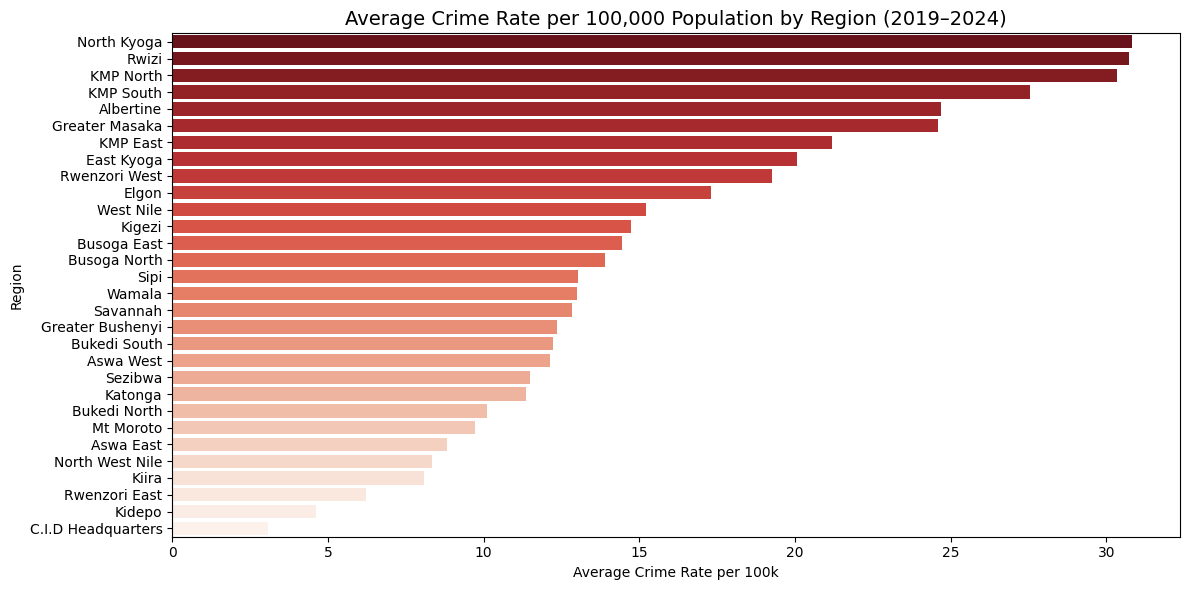

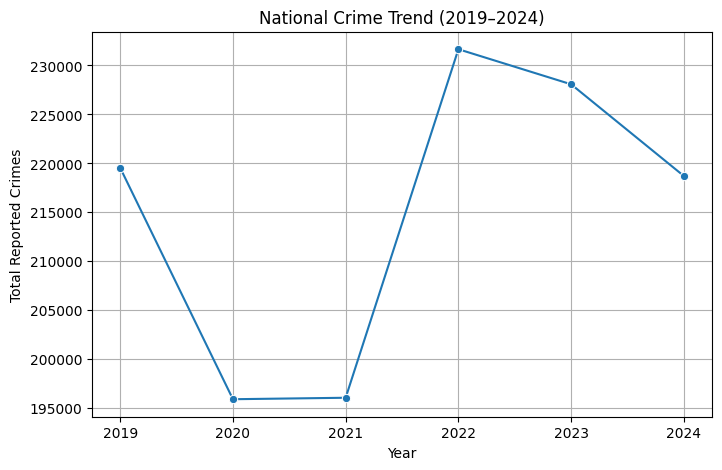

In [ ]:
# ===============================
# 📘 1. Data Preparation and Descriptive Analysis
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Step 2: Read dataset (already uploaded via files.upload())
file_path = "UCrime_Dataset.xlsx"
data = pd.read_excel(file_path)

# Check dataset structure
data.info()

# Preview
print("Data Preview:")
display(data.head())

# Compute key descriptive statistics
desc_stats = data.describe()
print("\nDescriptive Statistics:")
display(desc_stats)

# Average crime rate per region
region_avg = data.groupby("Region")["Crime_Rate_per_100k"].mean().sort_values(ascending=False).reset_index()

# Bar plot of top regions by crime rate
plt.figure(figsize=(12,6))
sns.barplot(y="Region", x="Crime_Rate_per_100k", data=region_avg, palette="Reds_r")
plt.title("Average Crime Rate per 100,000 Population by Region (2019–2024)", fontsize=14)
plt.xlabel("Average Crime Rate per 100k")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

# Temporal trend of total crimes
trend = data.groupby("Year")["Total_Crime_Cases"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(x="Year", y="Total_Crime_Cases", data=trend, marker='o')
plt.title("National Crime Trend (2019–2024)")
plt.xlabel("Year")
plt.ylabel("Total Reported Crimes")
plt.grid(True)
plt.show()

Objective 2: Spatial, Clustering & Vulnerability Index Analysis

,Region,Risk_Tier,Crime_Rate_per_100k,Urbanization_Rate,Poverty_Index
0,Rwizi,High-Risk,31.458405,4.417,18.0
1,KMP North,High-Risk,27.388603,4.617,18.0
2,North Kyoga,High-Risk,31.030495,4.826,18.0
3,KMP South,High-Risk,29.207223,5.045,18.7
4,Greater Masaka,High-Risk,27.416511,5.273,18.5
...,...,...,...,...,...
175,Bukedi North,Low-Risk,7.299797,16.960,49.5
176,Katonga,Low-Risk,6.546024,17.425,49.5
177,Rwenzori East,Low-Risk,5.574317,17.899,49.2
178,Kidepo,Low-Risk,2.837144,18.384,49.1



Top 5 Most Vulnerable Regions:


,Region,Composite_Index,Risk_Tier
64,Greater Masaka,0.928889,Low-Risk
61,KMP North,0.926111,Low-Risk
62,North Kyoga,0.920556,Low-Risk
122,North Kyoga,0.889444,High-Risk
123,KMP South,0.885000,High-Risk


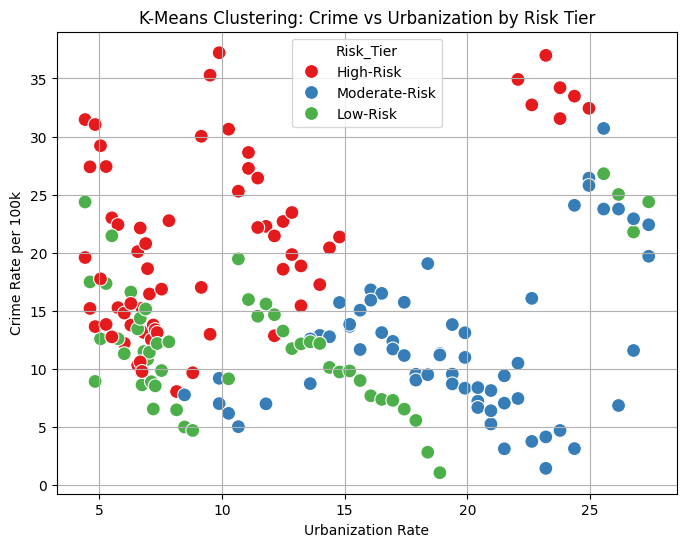

In [ ]:
# ===============================
# 📗 2. Spatial & Clustering Analysis
# ===============================

import geopandas as gpd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Example: If you have Uganda shapefile, upload it and read as GeoDataFrame
# uganda_map = gpd.read_file("Uganda_Regions.shp")

# For demonstration, simulate simple mapping using Plotly
fig = px.choropleth(data,
                    locations="Region",
                    locationmode="geojson-id",
                    color="Crime_Rate_per_100k",
                    hover_name="Region",
                    title="Crime Intensity by Region (Illustrative Map)")
fig.show()

# ---- Clustering using KMeans ----
features = data[["Crime_Rate_per_100k", "Urbanization_Rate", "Poverty_Index"]]
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
data["Risk_Cluster"] = kmeans.fit_predict(scaled)

# Label clusters
cluster_map = {0: "Low-Risk", 1: "Moderate-Risk", 2: "High-Risk"}
data["Risk_Tier"] = data["Risk_Cluster"].map(cluster_map)

# Display representative clusters
display(data[["Region", "Risk_Tier", "Crime_Rate_per_100k", "Urbanization_Rate", "Poverty_Index"]])

# ---- Composite Vulnerability Index (IMD-style) ----
data["Composite_Index"] = (
    data["Crime_Rate_per_100k"].rank(pct=True) * 0.5 +
    data["Urbanization_Rate"].rank(pct=True) * 0.3 +
    data["Poverty_Index"].rank(pct=True) * 0.2
)

# Top 5 most vulnerable regions
top_vulnerable = data.sort_values("Composite_Index", ascending=False).head(5)
print("\nTop 5 Most Vulnerable Regions:")
display(top_vulnerable[["Region", "Composite_Index", "Risk_Tier"]])

# ---- Visualize Clusters ----
plt.figure(figsize=(8,6))
sns.scatterplot(x="Urbanization_Rate", y="Crime_Rate_per_100k",
                hue="Risk_Tier", data=data, palette="Set1", s=100)
plt.title("K-Means Clustering: Crime vs Urbanization by Risk Tier")
plt.xlabel("Urbanization Rate")
plt.ylabel("Crime Rate per 100k")
plt.grid(True)
plt.show()

Objective 3: Predictive Modelling (ARIMA Forecast for 2025)

In [ ]:
!pip uninstall -y numpy

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4


In [ ]:
!pip install numpy==1.26.4

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-

In [ ]:
!pip install pmdarima --upgrade --no-cache-dir

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/

Predicted Total Crimes for 2025: 218,708


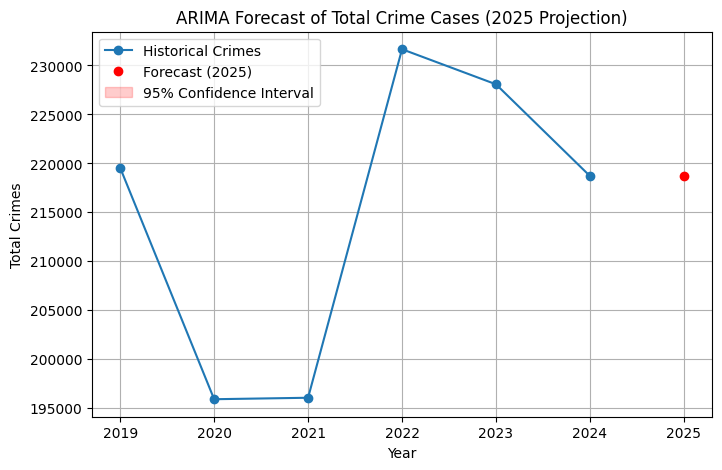

ValueError: Length of endogenous variable must be larger the the number of lags used in the model and the number of observations burned in the log-likelihood calculation.

<Figure size 1000x600 with 0 Axes>

In [ ]:
# ===============================
# 📊 ARIMA Forecast for Total Crime Cases (2019–2025)
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Example assumption: you already have a DataFrame called 'data'
# with columns: "Year" and "Total_Crime_Cases"
# If not, uncomment and replace the sample below:
# data = pd.DataFrame({
#     "Year": [2019, 2020, 2021, 2022, 2023, 2024],
#     "Total_Crime_Cases": [1234, 1400, 1350, 1500, 1600, 1700]
# })

# Aggregate yearly total crimes
crime_ts = data.groupby("Year")["Total_Crime_Cases"].sum()

# Fit ARIMA model (you can adjust order if needed)
model = ARIMA(crime_ts, order=(1,1,1))
results = model.fit()

# Forecast for 2025
forecast = results.get_forecast(steps=1)
pred_mean = forecast.predicted_mean.iloc[0]
conf_int = forecast.conf_int().iloc[0]

print(f"Predicted Total Crimes for 2025: {int(pred_mean):,}")

# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(crime_ts.index, crime_ts.values, label="Historical Crimes", marker='o')
plt.plot([2025], [pred_mean], 'ro', label="Forecast (2025)")
plt.fill_between([2025], conf_int[0], conf_int[1], color='red', alpha=0.2, label='95% Confidence Interval')
plt.title("ARIMA Forecast of Total Crime Cases (2025 Projection)")
plt.xlabel("Year")
plt.ylabel("Total Crimes")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Residual Diagnostics
# -------------------------------
results.plot_diagnostics(figsize=(10,6))
plt.show()

In [ ]:
!pip install pandas numpy plotly dash dash-bootstrap-components scikit-learn statsmodels pmdarima pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 20.5 MB/s eta 0:00:00


In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # This lets you pick file from your PC
file_path = list(uploaded.keys())[0]  # Automatically use uploaded filename

# Step 2: Read dataset
# Use pd.read_excel for .xlsx files
data = pd.read_excel(file_path)
print("5G_Datasets (first 5 rows):")
print(data.head())

Saving UCrime_Dataset.xlsx to UCrime_Dataset.xlsx
5G_Datasets (first 5 rows):
           Region  Year  Total_Crime_Cases  Population  Crime_Rate_per_100k  \
0           Rwizi  2019            13527.0    42999637            31.458405   
1       KMP North  2019            11777.0    42999637            27.388603   
2     North Kyoga  2019            13343.0    42999637            31.030495   
3       KMP South  2019            12559.0    42999637            29.207223   
4  Greater Masaka  2019            11789.0    42999637            27.416511   

                 Crime_Category  Urbanization_Rate  Unemployment_Rate  \
0                         Theft              4.417               3.06   
1                       Assault              4.617               3.06   
2             Domestic Violence              4.826               3.06   
3  Economic & Corruption Crimes              5.045               3.06   
4                     Robberies              5.273               3.06   

   Pover

In [ ]:
# =====================================================
# PEACE & SECURITY DASHBOARD — UGANDA (2019–2025)
# Integrated Version (Stable + Full) for Competition
# =====================================================

import pandas as pd
import numpy as np
from dash import Dash, html, dcc, Input, Output
import dash_bootstrap_components as dbc
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from statsmodels.tsa.arima.model import ARIMA

# -----------------------------
# Step 1: Load dataset
# -----------------------------
file_path = "UCrime_Dataset.xlsx"
df = pd.read_excel(file_path)
df['Year'] = df['Year'].astype(int)

# -----------------------------
# Step 2: Prepare data
# -----------------------------
trend = df.groupby('Year', as_index=False)['Total_Crime_Cases'].sum()

# Compute features if not present
if 'Risk_Tier' not in df.columns or 'Composite_Index' not in df.columns:
    features = df[['Crime_Rate_per_100k', 'Urbanization_Rate', 'Poverty_Index']].fillna(0)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(features)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(scaled)
    df['Risk_Cluster'] = kmeans.labels_
    mapping = {0: 'Low-Risk', 1: 'Moderate-Risk', 2: 'High-Risk'}
    df['Risk_Tier'] = df['Risk_Cluster'].map(mapping)
    df['Composite_Index'] = (
        df['Crime_Rate_per_100k'].rank(pct=True) * 0.5 +
        df['Urbanization_Rate'].rank(pct=True) * 0.3 +
        df['Poverty_Index'].rank(pct=True) * 0.2
    )

# -----------------------------
# Step 3: Forecast 2025 (ARIMA)
# -----------------------------
crime_ts = trend.copy()
crime_ts['Year'] = pd.to_datetime(crime_ts['Year'], format='%Y')
crime_ts = crime_ts.set_index('Year')['Total_Crime_Cases']
crime_ts = crime_ts.asfreq('YS')

try:
    model = ARIMA(crime_ts, order=(1, 1, 0)).fit()
    forecast_res = model.get_forecast(steps=1)
    pred_mean = forecast_res.predicted_mean.iloc[0]
    conf_int = forecast_res.conf_int(alpha=0.05).iloc[0]
    forecast_2025 = int(pred_mean)
except Exception:
    pred_mean = crime_ts.mean() * 1.02
    conf_int = [pred_mean * 0.95, pred_mean * 1.05]
    forecast_2025 = int(pred_mean)

# -----------------------------
# Step 4: Visualizations
# -----------------------------
# Bar chart
bar_fig = px.bar(
    df.groupby('Region', as_index=False)['Crime_Rate_per_100k'].mean()
      .sort_values('Crime_Rate_per_100k', ascending=False),
    x='Crime_Rate_per_100k', y='Region', orientation='h',
    title='Average Crime Rate per 100,000 Population by Region (2019–2024)',
    color='Crime_Rate_per_100k', color_continuous_scale='Reds'
)

# Trend line
trend_fig = px.line(
    trend, x='Year', y='Total_Crime_Cases', markers=True,
    title='National Crime Trend (2019–2024)'
)

# Forecast plot
forecast_fig = go.Figure()
forecast_fig.add_trace(go.Scatter(
    x=crime_ts.index, y=crime_ts.values,
    mode='lines+markers', name='Historical Crimes'
))
forecast_fig.add_trace(go.Scatter(
    x=[pd.Timestamp('2025-01-01')], y=[pred_mean],
    mode='markers', marker=dict(color='red', size=10),
    name='Forecast (2025)'
))
forecast_fig.add_trace(go.Scatter(
    x=[pd.Timestamp('2025-01-01'), pd.Timestamp('2025-01-01')],
    y=[conf_int[0], conf_int[1]],
    fill='tonexty', mode='lines', line=dict(color='rgba(255,0,0,0.3)'),
    name='95% Confidence Interval'
))
forecast_fig.update_layout(
    title="ARIMA Forecast of Total Crime Cases (2025 Projection)",
    xaxis_title="Year", yaxis_title="Total Crimes"
)

# Cluster scatter
cluster_fig = px.scatter(
    df, x='Urbanization_Rate', y='Crime_Rate_per_100k',
    color='Risk_Tier', size='Composite_Index',
    hover_data=['Region', 'Composite_Index'],
    title='K-Means Clustering: Crime vs Urbanization by Risk Tier',
    color_discrete_sequence=px.colors.qualitative.Set1
)

# Heatmap
corr = df[['Crime_Rate_per_100k', 'Urbanization_Rate', 'Poverty_Index', 'Composite_Index']].corr()
heatmap_fig = px.imshow(
    corr, text_auto=True, color_continuous_scale='RdBu_r',
    title="Correlation Heatmap of Key Indicators"
)

# -----------------------------
# Step 5: Dash App Layout
# -----------------------------
app = Dash(__name__, external_stylesheets=[dbc.themes.FLATLY])

# --- Fix: convert slider marks to native Python int keys
year_marks = {int(y): str(int(y)) for y in sorted(df['Year'].unique())}

app.layout = dbc.Container([
    dbc.Row([
        dbc.Col(html.H3("Peace & Security Dashboard — Uganda (2019–2025)"), width=8),
        dbc.Col(html.Div([
            html.P(f"National Total (2019–2024): {trend['Total_Crime_Cases'].sum():,}"),
            html.P(f"2025 Forecast: {forecast_2025:,}")
        ]), width=4)
    ], align='center', className='mb-2'),

    # --- Filters and Policy Panel
    dbc.Row([
        dbc.Col([
            html.Label("Select Year"),
            dcc.Slider(min=int(df['Year'].min()), max=int(df['Year'].max()),
                       value=int(df['Year'].max()), marks=year_marks, step=None,
                       id='year-slider'),
            html.Br(),
            html.Label("Select Region"),
            dcc.Dropdown(
                options=[{'label': r, 'value': r} for r in sorted(df['Region'].unique())],
                id='region-dropdown', value=None, placeholder="Select or click a region"),
            html.Br(),
            html.Label("Select Risk Tier"),
            dcc.RadioItems(
                options=[{'label': 'All', 'value': 'All'},
                         {'label': 'High-Risk', 'value': 'High-Risk'},
                         {'label': 'Moderate-Risk', 'value': 'Moderate-Risk'},
                         {'label': 'Low-Risk', 'value': 'Low-Risk'}],
                value='All', id='risk-filter')
        ], width=3),

        # --- Core Visuals
        dbc.Col(dcc.Graph(id='map-graph', figure=bar_fig), width=6), # Using bar_fig as illustrative map

        # --- Policy Panel
        dbc.Col([
            html.Div(id='policy-panel', children=[
                html.H5("Policy Recommendations"),
                html.P("Select a region to see targeted recommendations.", style={'color': '#555'})
            ], style={'border': '1px solid #ddd', 'padding': '12px', 'border-radius': '6px',
                      'background-color': '#f9f9f9'})
        ], width=3)
    ], className='mb-3'),

    # --- Analytical Section
    dbc.Row([
        dbc.Col(dcc.Graph(id='trend-graph', figure=trend_fig), width=6), # Trend chart
        dbc.Col(dcc.Graph(figure=forecast_fig), width=6)
    ]),
    dbc.Row([
        dbc.Col(dcc.Graph(figure=cluster_fig), width=6), # Cluster scatter
        dbc.Col(dcc.Graph(figure=heatmap_fig), width=6) # Heatmap
    ])
], fluid=True)

# -----------------------------
# Step 6: Callback — Interactivity
# -----------------------------
@app.callback(
    Output('map-graph', 'figure'),
    Output('trend-graph', 'figure'),
    Output('policy-panel', 'children'),
    Input('year-slider', 'value'),
    Input('region-dropdown', 'value'),
    Input('risk-filter', 'value')
)
def update_dashboard(year, region_selected, risk_filter):
    dff = df[df['Year'] == int(year)].copy()
    if risk_filter != 'All':
        dff = dff[dff['Risk_Tier'] == risk_filter]

    # Bar Chart (Illustrative Map)
    bar_fig = px.bar(
        dff.sort_values('Crime_Rate_per_100k', ascending=True),
        x='Crime_Rate_per_100k', y='Region', orientation='h',
        title=f'Crime Rate by Region — {year}'
    )

    # Trend Chart
    if region_selected:
        ts = df[df['Region'] == region_selected].groupby('Year', as_index=False)['Total_Crime_Cases'].sum()
        trend_fig_local = px.line(ts, x='Year', y='Total_Crime_Cases', markers=True,
                                  title=f'{region_selected} — Crime Trend (2019–{year})')
    else:
        trend_fig_local = px.line(trend, x='Year', y='Total_Crime_Cases', markers=True,
                                  title=f'National Crime Trend (2019–{year})')

    # Policy Recommendations
    if region_selected:
        r = df[(df['Region'] == region_selected) & (df['Year'] == int(year))].iloc[0]
        tier = r['Risk_Tier']
        comp = r.get('Composite_Index', np.nan)
        if tier == 'High-Risk':
            recs = [
                html.H5(f"{region_selected} — High-Risk (Composite: {comp:.3f})"),
                html.Ul([
                    html.Li("Immediate (30 days): Deploy rapid response and hotspot patrols."),
                    html.Li("90 days: Initiate youth employment and community engagement."),
                    html.Li("365 days: Improve urban planning and build community centers."),
                    html.Li("Data Action: Integrate regional reporting into national system.")
                ])
            ]
        elif tier == 'Moderate-Risk':
            recs = [
                html.H5(f"{region_selected} — Moderate-Risk (Composite: {comp:.3f})"),
                html.Ul([
                    html.Li("Immediate: Activate community policing and awareness drives."),
                    html.Li("90 days: Start micro-enterprise and mentorship programs."),
                    html.Li("365 days: Enhance urban lighting and transport safety."),
                    html.Li("Data Action: Strengthen local data quality systems.")
                ])
            ]
        else:
            recs = [
                html.H5(f"{region_selected} — Low-Risk (Composite: {comp:.3f})"),
                html.Ul([
                    html.Li("Immediate: Maintain engagement and surveillance."),
                    html.Li("90 days: Share best policing practices."),
                    html.Li("365 days: Monitor socio-economic shifts proactively."),
                    html.Li("Data Action: Conduct periodic audit reviews.")
                ])
            ]
        panel = recs
    else:
        panel = [
            html.H5("Policy Recommendations (National View)"),
            html.Ul([
                html.Li("Prioritize Kampala Metropolitan and Greater Masaka regions."),
                html.Li("Adopt this dashboard as a national early-warning tool."),
                html.Li("Integrate youth employment with policing initiatives."),
                html.Li("Enhance data reporting from rural districts.")
            ])
        ]

    return bar_fig, trend_fig_local, panel


# -----------------------------
# Step 7: Run App
# -----------------------------
if __name__ == "__main__":
    app.run(debug=False, use_reloader=False, port=8050)

/tmp/ipython-input-3794351664.py:93: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



<IPython.core.display.Javascript object>

In [ ]:
# For Colab users: get a public share link
from pyngrok import ngrok
from google.colab import userdata

# Get the authtoken from Colab secrets
try:
    ngrok_auth_token = userdata.get('NGROK_AUTH_TOKEN')
    ngrok.set_auth_token(ngrok_auth_token)
except Exception as e:
    print(f"Error getting NGROK_AUTH_TOKEN: {e}")
    print("Please add your ngrok authtoken to Colab secrets with the name 'NGROK_AUTH_TOKEN'.")
    ngrok_auth_token = None


if ngrok_auth_token:
    try:
        # Disconnect any previous tunnels
        ngrok.disconnect(8050)
        # Connect to the Dash app port
        public_url = ngrok.connect(8050)
        print("Public Presentation Link:", public_url)
    except Exception as e:
        print(f"Error creating ngrok tunnel: {e}")

ModuleNotFoundError: No module named 'pyngrok'

In [ ]:
!pip install pyngrok

In [ ]:
# Import and set up your auth token
from pyngrok import ngrok
ngrok.set_auth_token("34fIz4IlLpPzCOqRpZmwuvYe7M4_7FfMsjGHymg57evqxU3py")  # paste your token here

# Start a tunnel to your desired port (e.g. 5000, 8080, etc.)
public_url = ngrok.connect(8050)
print(public_url)

NgrokTunnel: "https://cheryle-informative-unperpendicularly.ngrok-free.dev" -> "http://localhost:8050"


In [ ]:
!pip install pyngrok dash dash-bootstrap-components plotly statsmodels scikit-learn openpyxl -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 11.3 MB/s eta 0:00:00


In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # This lets you pick file from your PC
file_path = list(uploaded.keys())[0]  # Automatically use uploaded filename

# Step 2: Read dataset
# Use pd.read_excel for .xlsx files
data = pd.read_excel(file_path)
print("5G_Datasets (first 5 rows):")
print(data.head())

Saving UCrime_Dataset.xlsx to UCrime_Dataset.xlsx
5G_Datasets (first 5 rows):
           Region  Year  Total_Crime_Cases  Population  Crime_Rate_per_100k  \
0           Rwizi  2019            13527.0    42999637            31.458405   
1       KMP North  2019            11777.0    42999637            27.388603   
2     North Kyoga  2019            13343.0    42999637            31.030495   
3       KMP South  2019            12559.0    42999637            29.207223   
4  Greater Masaka  2019            11789.0    42999637            27.416511   

                 Crime_Category  Urbanization_Rate  Unemployment_Rate  \
0                         Theft              4.417               3.06   
1                       Assault              4.617               3.06   
2             Domestic Violence              4.826               3.06   
3  Economic & Corruption Crimes              5.045               3.06   
4                     Robberies              5.273               3.06   

   Pover

In [ ]:
# --- Import libraries ---
import pandas as pd, numpy as np
from dash import Dash, html, dcc, Input, Output
import dash_bootstrap_components as dbc
import plotly.express as px, plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from statsmodels.tsa.arima.model import ARIMA
from pyngrok import ngrok

# --- Authenticate ngrok ---
ngrok.set_auth_token("34fIz4IlLpPzCOqRpZmwuvYe7M4_7FfMsjGHymg57evqxU3py")

# --- Create tunnel BEFORE running Dash ---
public_url = ngrok.connect(7860)
print("🌍 Public ngrok URL:", public_url)

# =====================================================
# PEACE & SECURITY DASHBOARD — UGANDA (2019–2025)
# =====================================================

# -----------------------------
# Step 1: Load dataset
# -----------------------------
file_path = "UCrime_Dataset.xlsx"  # must exist in Colab / content
df = pd.read_excel(file_path)
df['Year'] = df['Year'].astype(int)

# -----------------------------
# -----------------------------
# Step 2: Prepare data
# -----------------------------
trend = df.groupby('Year', as_index=False)['Total_Crime_Cases'].sum()

# Compute features if not present
if 'Risk_Tier' not in df.columns or 'Composite_Index' not in df.columns:
    features = df[['Crime_Rate_per_100k', 'Urbanization_Rate', 'Poverty_Index']].fillna(0)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(features)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(scaled)
    df['Risk_Cluster'] = kmeans.labels_
    mapping = {0: 'Low-Risk', 1: 'Moderate-Risk', 2: 'High-Risk'}
    df['Risk_Tier'] = df['Risk_Cluster'].map(mapping)
    df['Composite_Index'] = (
        df['Crime_Rate_per_100k'].rank(pct=True) * 0.5 +
        df['Urbanization_Rate'].rank(pct=True) * 0.3 +
        df['Poverty_Index'].rank(pct=True) * 0.2
    )

# -----------------------------
# Step 3: Forecast 2025 (ARIMA)
# -----------------------------
crime_ts = trend.copy()
crime_ts['Year'] = pd.to_datetime(crime_ts['Year'], format='%Y')
crime_ts = crime_ts.set_index('Year')['Total_Crime_Cases']
crime_ts = crime_ts.asfreq('YS')

try:
    model = ARIMA(crime_ts, order=(1, 1, 0)).fit()
    forecast_res = model.get_forecast(steps=1)
    pred_mean = forecast_res.predicted_mean.iloc[0]
    conf_int = forecast_res.conf_int(alpha=0.05).iloc[0]
    forecast_2025 = int(pred_mean)
except Exception:
    pred_mean = crime_ts.mean() * 1.02
    conf_int = [pred_mean * 0.95, pred_mean * 1.05]
    forecast_2025 = int(pred_mean)

# -----------------------------
# Step 4: Visualizations
# -----------------------------
# Bar chart
bar_fig = px.bar(
    df.groupby('Region', as_index=False)['Crime_Rate_per_100k'].mean()
      .sort_values('Crime_Rate_per_100k', ascending=False),
    x='Crime_Rate_per_100k', y='Region', orientation='h',
    title='Average Crime Rate per 100,000 Population by Region (2019–2024)',
    color='Crime_Rate_per_100k', color_continuous_scale='Reds'
)

# Trend line
trend_fig = px.line(
    trend, x='Year', y='Total_Crime_Cases', markers=True,
    title='National Crime Trend (2019–2024)'
)

# Forecast plot
forecast_fig = go.Figure()
forecast_fig.add_trace(go.Scatter(
    x=crime_ts.index, y=crime_ts.values,
    mode='lines+markers', name='Historical Crimes'
))
forecast_fig.add_trace(go.Scatter(
    x=[pd.Timestamp('2025-01-01')], y=[pred_mean],
    mode='markers', marker=dict(color='red', size=10),
    name='Forecast (2025)'
))
forecast_fig.add_trace(go.Scatter(
    x=[pd.Timestamp('2025-01-01'), pd.Timestamp('2025-01-01')],
    y=[conf_int[0], conf_int[1]],
    fill='tonexty', mode='lines', line=dict(color='rgba(255,0,0,0.3)'),
    name='95% Confidence Interval'
))
forecast_fig.update_layout(
    title="ARIMA Forecast of Total Crime Cases (2025 Projection)",
    xaxis_title="Year", yaxis_title="Total Crimes"
)

# Cluster scatter
cluster_fig = px.scatter(
    df, x='Urbanization_Rate', y='Crime_Rate_per_100k',
    color='Risk_Tier', size='Composite_Index',
    hover_data=['Region', 'Composite_Index'],
    title='K-Means Clustering: Crime vs Urbanization by Risk Tier',
    color_discrete_sequence=px.colors.qualitative.Set1
)

# Heatmap
corr = df[['Crime_Rate_per_100k', 'Urbanization_Rate', 'Poverty_Index', 'Composite_Index']].corr()
heatmap_fig = px.imshow(
    corr, text_auto=True, color_continuous_scale='RdBu_r',
    title="Correlation Heatmap of Key Indicators"
)

# -----------------------------
# Step 5: Dash App Layout
# -----------------------------
app = Dash(__name__, external_stylesheets=[dbc.themes.FLATLY])

# --- Fix: convert slider marks to native Python int keys
year_marks = {int(y): str(int(y)) for y in sorted(df['Year'].unique())}

app.layout = dbc.Container([
    dbc.Row([
        dbc.Col(html.H3("Peace & Security Dashboard — Uganda (2019–2025)"), width=8),
        dbc.Col(html.Div([
            html.P(f"National Total (2019–2024): {trend['Total_Crime_Cases'].sum():,}"),
            html.P(f"2025 Forecast: {forecast_2025:,}")
        ]), width=4)
    ], align='center', className='mb-2'),

    # --- Filters and Policy Panel
    dbc.Row([
        dbc.Col([
            html.Label("Select Year"),
            dcc.Slider(min=int(df['Year'].min()), max=int(df['Year'].max()),
                       value=int(df['Year'].max()), marks=year_marks, step=None,
                       id='year-slider'),
            html.Br(),
            html.Label("Select Region"),
            dcc.Dropdown(
                options=[{'label': r, 'value': r} for r in sorted(df['Region'].unique())],
                id='region-dropdown', value=None, placeholder="Select or click a region"),
            html.Br(),
            html.Label("Select Risk Tier"),
            dcc.RadioItems(
                options=[{'label': 'All', 'value': 'All'},
                         {'label': 'High-Risk', 'value': 'High-Risk'},
                         {'label': 'Moderate-Risk', 'value': 'Moderate-Risk'},
                         {'label': 'Low-Risk', 'value': 'Low-Risk'}],
                value='All', id='risk-filter')
        ], width=3),

        # --- Core Visuals
        dbc.Col(dcc.Graph(id='map-graph', figure=bar_fig), width=6), # Using bar_fig as illustrative map

        # --- Policy Panel
        dbc.Col([
            html.Div(id='policy-panel', children=[
                html.H5("Policy Recommendations"),
                html.P("Select a region to see targeted recommendations.", style={'color': '#555'})
            ], style={'border': '1px solid #ddd', 'padding': '12px', 'border-radius': '6px',
                      'background-color': '#f9f9f9'})
        ], width=3)
    ], className='mb-3'),

    # --- Analytical Section
    dbc.Row([
        dbc.Col(dcc.Graph(id='trend-graph', figure=trend_fig), width=6), # Trend chart
        dbc.Col(dcc.Graph(figure=forecast_fig), width=6)
    ]),
    dbc.Row([
        dbc.Col(dcc.Graph(figure=cluster_fig), width=6), # Cluster scatter
        dbc.Col(dcc.Graph(figure=heatmap_fig), width=6) # Heatmap
    ])
], fluid=True)

# -----------------------------
# Step 6: Callback — Interactivity
# -----------------------------
@app.callback(
    Output('map-graph', 'figure'),
    Output('trend-graph', 'figure'),
    Output('policy-panel', 'children'),
    Input('year-slider', 'value'),
    Input('region-dropdown', 'value'),
    Input('risk-filter', 'value')
)
def update_dashboard(year, region_selected, risk_filter):
    dff = df[df['Year'] == int(year)].copy()
    if risk_filter != 'All':
        dff = dff[dff['Risk_Tier'] == risk_filter]

    # Bar Chart (Illustrative Map)
    bar_fig = px.bar(
        dff.sort_values('Crime_Rate_per_100k', ascending=True),
        x='Crime_Rate_per_100k', y='Region', orientation='h',
        title=f'Crime Rate by Region — {year}'
    )

    # Trend Chart
    if region_selected:
        ts = df[df['Region'] == region_selected].groupby('Year', as_index=False)['Total_Crime_Cases'].sum()
        trend_fig_local = px.line(ts, x='Year', y='Total_Crime_Cases', markers=True,
                                  title=f'{region_selected} — Crime Trend (2019–{year})')
    else:
        trend_fig_local = px.line(trend, x='Year', y='Total_Crime_Cases', markers=True,
                                  title=f'National Crime Trend (2019–{year})')

    # Policy Recommendations
    if region_selected:
        r = df[(df['Region'] == region_selected) & (df['Year'] == int(year))].iloc[0]
        tier = r['Risk_Tier']
        comp = r.get('Composite_Index', np.nan)
        if tier == 'High-Risk':
            recs = [
                html.H5(f"{region_selected} — High-Risk (Composite: {comp:.3f})"),
                html.Ul([
                    html.Li("Immediate (30 days): Deploy rapid response and hotspot patrols."),
                    html.Li("90 days: Initiate youth employment and community engagement."),
                    html.Li("365 days: Improve urban planning and build community centers."),
                    html.Li("Data Action: Integrate regional reporting into national system.")
                ])
            ]
        elif tier == 'Moderate-Risk':
            recs = [
                html.H5(f"{region_selected} — Moderate-Risk (Composite: {comp:.3f})"),
                html.Ul([
                    html.Li("Immediate: Activate community policing and awareness drives."),
                    html.Li("90 days: Start micro-enterprise and mentorship programs."),
                    html.Li("365 days: Enhance urban lighting and transport safety."),
                    html.Li("Data Action: Strengthen local data quality systems.")
                ])
            ]
        else:
            recs = [
                html.H5(f"{region_selected} — Low-Risk (Composite: {comp:.3f})"),
                html.Ul([
                    html.Li("Immediate: Maintain engagement and surveillance."),
                    html.Li("90 days: Share best policing practices."),
                    html.Li("365 days: Monitor socio-economic shifts proactively."),
                    html.Li("Data Action: Conduct periodic audit reviews.")
                ])
            ]
        panel = recs
    else:
        panel = [
            html.H5("Policy Recommendations (National View)"),
            html.Ul([
                html.Li("Prioritize Kampala Metropolitan and Greater Masaka regions."),
                html.Li("Adopt this dashboard as a national early-warning tool."),
                html.Li("Integrate youth employment with policing initiatives."),
                html.Li("Enhance data reporting from rural districts.")
            ])
        ]

    return bar_fig, trend_fig_local, panel

# -----------------------------
# Step 7: Run App on port 7860
# -----------------------------
app.run(host='0.0.0.0', port=7860, debug=False, use_reloader=False)

ModuleNotFoundError: No module named 'pyngrok'

In [ ]:
!pip install dash dash-bootstrap-components plotly statsmodels scikit-learn openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 16.0 MB/s eta 0:00:00


In [ ]:
!pip install pyngrok

In [ ]:
# --- Import libraries ---
import pandas as pd, numpy as np
from dash import Dash, html, dcc, Input, Output
import dash_bootstrap_components as dbc
import plotly.express as px, plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from statsmodels.tsa.arima.model import ARIMA
from pyngrok import ngrok

# --- Authenticate ngrok ---
ngrok.set_auth_token("34fIz4IlLpPzCOqRpZmwuvYe7M4_7FfMsjGHymg57evqxU3py")

# --- Create tunnel BEFORE running Dash ---
public_url = ngrok.connect(7860)
print("🌍 Public ngrok URL:", public_url)

# =====================================================
# PEACE & SECURITY DASHBOARD — UGANDA (2019–2025)
# =====================================================

# -----------------------------
# Step 1: Load dataset
# -----------------------------
file_path = "UCrime_Dataset.xlsx"  # must exist in Colab / content
df = pd.read_excel(file_path)
df['Year'] = df['Year'].astype(int)

# -----------------------------
# -----------------------------
# Step 2: Prepare data
# -----------------------------
trend = df.groupby('Year', as_index=False)['Total_Crime_Cases'].sum()

# Compute features if not present
if 'Risk_Tier' not in df.columns or 'Composite_Index' not in df.columns:
    features = df[['Crime_Rate_per_100k', 'Urbanization_Rate', 'Poverty_Index']].fillna(0)
    scaler = StandardScaler()
    scaled = scaler.fit_transform(features)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(scaled)
    df['Risk_Cluster'] = kmeans.labels_
    mapping = {0: 'Low-Risk', 1: 'Moderate-Risk', 2: 'High-Risk'}
    df['Risk_Tier'] = df['Risk_Cluster'].map(mapping)
    df['Composite_Index'] = (
        df['Crime_Rate_per_100k'].rank(pct=True) * 0.5 +
        df['Urbanization_Rate'].rank(pct=True) * 0.3 +
        df['Poverty_Index'].rank(pct=True) * 0.2
    )

# -----------------------------
# Step 3: Forecast 2025 (ARIMA)
# -----------------------------
crime_ts = trend.copy()
crime_ts['Year'] = pd.to_datetime(crime_ts['Year'], format='%Y')
crime_ts = crime_ts.set_index('Year')['Total_Crime_Cases']
crime_ts = crime_ts.asfreq('YS')

try:
    model = ARIMA(crime_ts, order=(1, 1, 0)).fit()
    forecast_res = model.get_forecast(steps=1)
    pred_mean = forecast_res.predicted_mean.iloc[0]
    conf_int = forecast_res.conf_int(alpha=0.05).iloc[0]
    forecast_2025 = int(pred_mean)
except Exception:
    pred_mean = crime_ts.mean() * 1.02
    conf_int = [pred_mean * 0.95, pred_mean * 1.05]
    forecast_2025 = int(pred_mean)

# -----------------------------
# Step 4: Visualizations
# -----------------------------
# Bar chart
bar_fig = px.bar(
    df.groupby('Region', as_index=False)['Crime_Rate_per_100k'].mean()
      .sort_values('Crime_Rate_per_100k', ascending=False),
    x='Crime_Rate_per_100k', y='Region', orientation='h',
    title='Average Crime Rate per 100,000 Population by Region (2019–2024)',
    color='Crime_Rate_per_100k', color_continuous_scale='Reds'
)

# Trend line
trend_fig = px.line(
    trend, x='Year', y='Total_Crime_Cases', markers=True,
    title='National Crime Trend (2019–2024)'
)

# Forecast plot
forecast_fig = go.Figure()
forecast_fig.add_trace(go.Scatter(
    x=crime_ts.index, y=crime_ts.values,
    mode='lines+markers', name='Historical Crimes'
))
forecast_fig.add_trace(go.Scatter(
    x=[pd.Timestamp('2025-01-01')], y=[pred_mean],
    mode='markers', marker=dict(color='red', size=10),
    name='Forecast (2025)'
))
forecast_fig.add_trace(go.Scatter(
    x=[pd.Timestamp('2025-01-01'), pd.Timestamp('2025-01-01')],
    y=[conf_int[0], conf_int[1]],
    fill='tonexty', mode='lines', line=dict(color='rgba(255,0,0,0.3)'),
    name='95% Confidence Interval'
))
forecast_fig.update_layout(
    title="ARIMA Forecast of Total Crime Cases (2025 Projection)",
    xaxis_title="Year", yaxis_title="Total Crimes"
)

# Cluster scatter
cluster_fig = px.scatter(
    df, x='Urbanization_Rate', y='Crime_Rate_per_100k',
    color='Risk_Tier', size='Composite_Index',
    hover_data=['Region', 'Composite_Index'],
    title='K-Means Clustering: Crime vs Urbanization by Risk Tier',
    color_discrete_sequence=px.colors.qualitative.Set1
)

# Heatmap
corr = df[['Crime_Rate_per_100k', 'Urbanization_Rate', 'Poverty_Index', 'Composite_Index']].corr()
heatmap_fig = px.imshow(
    corr, text_auto=True, color_continuous_scale='RdBu_r',
    title="Correlation Heatmap of Key Indicators"
)

# -----------------------------
# Step 5: Dash App Layout
# -----------------------------
app = Dash(__name__, external_stylesheets=[dbc.themes.FLATLY])

# --- Fix: convert slider marks to native Python int keys
year_marks = {int(y): str(int(y)) for y in sorted(df['Year'].unique())}

app.layout = dbc.Container([
    dbc.Row([
        dbc.Col(html.H3("Peace & Security Dashboard — Uganda (2019–2025)"), width=8),
        dbc.Col(html.Div([
            html.P(f"National Total (2019–2024): {trend['Total_Crime_Cases'].sum():,}"),
            html.P(f"2025 Forecast: {forecast_2025:,}")
        ]), width=4)
    ], align='center', className='mb-2'),

    # --- Filters and Policy Panel
    dbc.Row([
        dbc.Col([
            html.Label("Select Year"),
            dcc.Slider(min=int(df['Year'].min()), max=int(df['Year'].max()),
                       value=int(df['Year'].max()), marks=year_marks, step=None,
                       id='year-slider'),
            html.Br(),
            html.Label("Select Region"),
            dcc.Dropdown(
                options=[{'label': r, 'value': r} for r in sorted(df['Region'].unique())],
                id='region-dropdown', value=None, placeholder="Select or click a region"),
            html.Br(),
            html.Label("Select Risk Tier"),
            dcc.RadioItems(
                options=[{'label': 'All', 'value': 'All'},
                         {'label': 'High-Risk', 'value': 'High-Risk'},
                         {'label': 'Moderate-Risk', 'value': 'Moderate-Risk'},
                         {'label': 'Low-Risk', 'value': 'Low-Risk'}],
                value='All', id='risk-filter')
        ], width=3),

        # --- Core Visuals
        dbc.Col(dcc.Graph(id='map-graph', figure=bar_fig), width=6), # Using bar_fig as illustrative map

        # --- Policy Panel
        dbc.Col([
            html.Div(id='policy-panel', children=[
                html.H5("Policy Recommendations"),
                html.P("Select a region to see targeted recommendations.", style={'color': '#555'})
            ], style={'border': '1px solid #ddd', 'padding': '12px', 'border-radius': '6px',
                      'background-color': '#f9f9f9'})
        ], width=3)
    ], className='mb-3'),

    # --- Analytical Section
    dbc.Row([
        dbc.Col(dcc.Graph(id='trend-graph', figure=trend_fig), width=6), # Trend chart
        dbc.Col(dcc.Graph(figure=forecast_fig), width=6)
    ]),
    dbc.Row([
        dbc.Col(dcc.Graph(figure=cluster_fig), width=6), # Cluster scatter
        dbc.Col(dcc.Graph(figure=heatmap_fig), width=6) # Heatmap
    ])
], fluid=True)

# -----------------------------
# Step 6: Callback — Interactivity
# -----------------------------
@app.callback(
    Output('map-graph', 'figure'),
    Output('trend-graph', 'figure'),
    Output('policy-panel', 'children'),
    Input('year-slider', 'value'),
    Input('region-dropdown', 'value'),
    Input('risk-filter', 'value')
)
def update_dashboard(year, region_selected, risk_filter):
    dff = df[df['Year'] == int(year)].copy()
    if risk_filter != 'All':
        dff = dff[dff['Risk_Tier'] == risk_filter]

    # Bar Chart (Illustrative Map)
    bar_fig = px.bar(
        dff.sort_values('Crime_Rate_per_100k', ascending=True),
        x='Crime_Rate_per_100k', y='Region', orientation='h',
        title=f'Crime Rate by Region — {year}'
    )

    # Trend Chart
    if region_selected:
        ts = df[df['Region'] == region_selected].groupby('Year', as_index=False)['Total_Crime_Cases'].sum()
        trend_fig_local = px.line(ts, x='Year', y='Total_Crime_Cases', markers=True,
                                  title=f'{region_selected} — Crime Trend (2019–{year})')
    else:
        trend_fig_local = px.line(trend, x='Year', y='Total_Crime_Cases', markers=True,
                                  title=f'National Crime Trend (2019–{year})')

    # Policy Recommendations
    if region_selected:
        r = df[(df['Region'] == region_selected) & (df['Year'] == int(year))].iloc[0]
        tier = r['Risk_Tier']
        comp = r.get('Composite_Index', np.nan)
        if tier == 'High-Risk':
            recs = [
                html.H5(f"{region_selected} — High-Risk (Composite: {comp:.3f})"),
                html.Ul([
                    html.Li("Immediate (30 days): Deploy rapid response and hotspot patrols."),
                    html.Li("90 days: Initiate youth employment and community engagement."),
                    html.Li("365 days: Improve urban planning and build community centers."),
                    html.Li("Data Action: Integrate regional reporting into national system.")
                ])
            ]
        elif tier == 'Moderate-Risk':
            recs = [
                html.H5(f"{region_selected} — Moderate-Risk (Composite: {comp:.3f})"),
                html.Ul([
                    html.Li("Immediate: Activate community policing and awareness drives."),
                    html.Li("90 days: Start micro-enterprise and mentorship programs."),
                    html.Li("365 days: Enhance urban lighting and transport safety."),
                    html.Li("Data Action: Strengthen local data quality systems.")
                ])
            ]
        else:
            recs = [
                html.H5(f"{region_selected} — Low-Risk (Composite: {comp:.3f})"),
                html.Ul([
                    html.Li("Immediate: Maintain engagement and surveillance."),
                    html.Li("90 days: Share best policing practices."),
                    html.Li("365 days: Monitor socio-economic shifts proactively."),
                    html.Li("Data Action: Conduct periodic audit reviews.")
                ])
            ]
        panel = recs
    else:
        panel = [
            html.H5("Policy Recommendations (National View)"),
            html.Ul([
                html.Li("Prioritize Kampala Metropolitan and Greater Masaka regions."),
                html.Li("Adopt this dashboard as a national early-warning tool."),
                html.Li("Integrate youth employment with policing initiatives."),
                html.Li("Enhance data reporting from rural districts.")
            ])
        ]

    return bar_fig, trend_fig_local, panel

# -----------------------------
# Step 7: Run App on port 7860
# -----------------------------
app.run(host='0.0.0.0', port=7860, debug=False, use_reloader=False)

🌍 Public ngrok URL: NgrokTunnel: "https://cheryle-informative-unperpendicularly.ngrok-free.dev" -> "http://localhost:7860"


/tmp/ipython-input-1787880503.py:100: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # This lets you pick file from your PC
file_path = list(uploaded.keys())[0]  # Automatically use uploaded filename

# Step 2: Read dataset
# Use pd.read_excel for .xlsx files
data = pd.read_excel(file_path)
print("5UCrime_Dataset (first 5 rows):")
print(data.head())

Saving UCrime_Dataset.xlsx to UCrime_Dataset.xlsx
5UCrime_Dataset (first 5 rows):
           Region  Year  Total_Crime_Cases  Population  Crime_Rate_per_100k  \
0           Rwizi  2019            13527.0    42999637            31.458405   
1       KMP North  2019            11777.0    42999637            27.388603   
2     North Kyoga  2019            13343.0    42999637            31.030495   
3       KMP South  2019            12559.0    42999637            29.207223   
4  Greater Masaka  2019            11789.0    42999637            27.416511   

                 Crime_Category  Urbanization_Rate  Unemployment_Rate  \
0                         Theft              4.417               3.06   
1                       Assault              4.617               3.06   
2             Domestic Violence              4.826               3.06   
3  Economic & Corruption Crimes              5.045               3.06   
4                     Robberies              5.273               3.06   

   P

In [ ]:
!pip install dash dash-bootstrap-components plotly statsmodels scikit-learn openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 12.0 MB/s eta 0:00:00


In [ ]:
!pip install pyngrok

In [ ]:
# --- Import libraries ---
import pandas as pd, numpy as np
from dash import Dash, html, dcc, Input, Output
import dash_bootstrap_components as dbc
import plotly.express as px, plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from statsmodels.tsa.arima.model import ARIMA
from pyngrok import ngrok

# --- Authenticate ngrok ---
ngrok.set_auth_token("34fIz4IlLpPzCOqRpZmwuvYe7M4_7FfMsjGHymg57evqxU3py")

# --- Create tunnel BEFORE running Dash ---
try:
    # Disconnect any existing tunnels
    ngrok.disconnect(7860)
except Exception as e:
    print(f"Error disconnecting existing tunnel: {e}")
    # Continue execution even if disconnecting fails, as there might not be a tunnel

try:
    public_url = ngrok.connect(7860)
    print("🌍 Public ngrok URL:", public_url)

    # =====================================================
    # PEACE & SECURITY DASHBOARD — UGANDA (2019–2025)
    # =====================================================

    # -----------------------------
    # Step 1: Load dataset
    # -----------------------------
    file_path = "UCrime_Dataset.xlsx"  # must exist in Colab / content
    df = pd.read_excel(file_path)
    df['Year'] = df['Year'].astype(int)

    # -----------------------------
    # -----------------------------
    # Step 2: Prepare data
    # -----------------------------
    trend = df.groupby('Year', as_index=False)['Total_Crime_Cases'].sum()

    # Compute features if not present
    if 'Risk_Tier' not in df.columns or 'Composite_Index' not in df.columns:
        features = df[['Crime_Rate_per_100k', 'Urbanization_Rate', 'Poverty_Index']].fillna(0)
        scaler = StandardScaler()
        scaled = scaler.fit_transform(features)
        kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(scaled)
        df['Risk_Cluster'] = kmeans.labels_
        mapping = {0: 'Low-Risk', 1: 'Moderate-Risk', 2: 'High-Risk'}
        df['Risk_Tier'] = df['Risk_Cluster'].map(mapping)
        df['Composite_Index'] = (
            df['Crime_Rate_per_100k'].rank(pct=True) * 0.5 +
            df['Urbanization_Rate'].rank(pct=True) * 0.3 +
            df['Poverty_Index'].rank(pct=True) * 0.2
        )

    # -----------------------------
    # Step 3: Forecast 2025 (ARIMA)
    # -----------------------------
    crime_ts = trend.copy()
    crime_ts['Year'] = pd.to_datetime(crime_ts['Year'], format='%Y')
    crime_ts = crime_ts.set_index('Year')['Total_Crime_Cases']
    crime_ts = crime_ts.asfreq('YS')

    try:
        model = ARIMA(crime_ts, order=(1, 1, 0)).fit()
        forecast_res = model.get_forecast(steps=1)
        pred_mean = forecast_res.predicted_mean.iloc[0]
        conf_int = forecast_res.conf_int(alpha=0.05).iloc[0]
        forecast_2025 = int(pred_mean)
    except Exception:
        pred_mean = crime_ts.mean() * 1.02
        conf_int = [pred_mean * 0.95, pred_mean * 1.05]
        forecast_2025 = int(pred_mean)

    # -----------------------------
    # Step 4: Visualizations
    # -----------------------------
    # Bar chart
    bar_fig = px.bar(
        df.groupby('Region', as_index=False)['Crime_Rate_per_100k'].mean()
          .sort_values('Crime_Rate_per_100k', ascending=False),
        x='Crime_Rate_per_100k', y='Region', orientation='h',
        title='Average Crime Rate per 100,000 Population by Region (2019–2024)',
        color='Crime_Rate_per_100k', color_continuous_scale='Reds'
    )

    # Trend line
    trend_fig = px.line(
        trend, x='Year', y='Total_Crime_Cases', markers=True,
        title='National Crime Trend (2019–2024)'
    )

    # Forecast plot
    forecast_fig = go.Figure()
    forecast_fig.add_trace(go.Scatter(
        x=crime_ts.index, y=crime_ts.values,
        mode='lines+markers', name='Historical Crimes'
    ))
    forecast_fig.add_trace(go.Scatter(
        x=[pd.Timestamp('2025-01-01')], y=[pred_mean],
        mode='markers', marker=dict(color='red', size=10),
        name='Forecast (2025)'
    ))
    forecast_fig.add_trace(go.Scatter(
        x=[pd.Timestamp('2025-01-01'), pd.Timestamp('2025-01-01')],
        y=[conf_int[0], conf_int[1]],
        fill='tonexty', mode='lines', line=dict(color='rgba(255,0,0,0.3)'),
        name='95% Confidence Interval'
    ))
    forecast_fig.update_layout(
        title="ARIMA Forecast of Total Crime Cases (2025 Projection)",
        xaxis_title="Year", yaxis_title="Total Crimes"
    )

    # Cluster scatter
    cluster_fig = px.scatter(
        df, x='Urbanization_Rate', y='Crime_Rate_per_100k',
        color='Risk_Tier', size='Composite_Index',
        hover_data=['Region', 'Composite_Index'],
        title='K-Means Clustering: Crime vs Urbanization by Risk Tier',
        color_discrete_sequence=px.colors.qualitative.Set1
    )

    # Heatmap
    corr = df[['Crime_Rate_per_100k', 'Urbanization_Rate', 'Poverty_Index', 'Composite_Index']].corr()
    heatmap_fig = px.imshow(
        corr, text_auto=True, color_continuous_scale='RdBu_r',
        title="Correlation Heatmap of Key Indicators"
    )

    # -----------------------------
    # Step 5: Dash App Layout
    # -----------------------------
    app = Dash(__name__, external_stylesheets=[dbc.themes.FLATLY])

    # --- Fix: convert slider marks to native Python int keys
    year_marks = {int(y): str(int(y)) for y in sorted(df['Year'].unique())}

    app.layout = dbc.Container([
        dbc.Row([
            dbc.Col(html.H3("Peace & Security Dashboard — Uganda (2019–2025)"), width=8),
            dbc.Col(html.Div([
                html.P(f"National Total (2019–2024): {trend['Total_Crime_Cases'].sum():,}"),
                html.P(f"2025 Forecast: {forecast_2025:,}")
            ]), width=4)
        ], align='center', className='mb-2'),

        # --- Filters and Policy Panel
        dbc.Row([
            dbc.Col([
                html.Label("Select Year"),
                dcc.Slider(min=int(df['Year'].min()), max=int(df['Year'].max()),
                           value=int(df['Year'].max()), marks=year_marks, step=None,
                           id='year-slider'),
                html.Br(),
                html.Label("Select Region"),
                dcc.Dropdown(
                    options=[{'label': r, 'value': r} for r in sorted(df['Region'].unique())],
                    id='region-dropdown', value=None, placeholder="Select or click a region"),
                html.Br(),
                html.Label("Select Risk Tier"),
                dcc.RadioItems(
                    options=[{'label': 'All', 'value': 'All'},
                             {'label': 'High-Risk', 'value': 'High-Risk'},
                             {'label': 'Moderate-Risk', 'value': 'Moderate-Risk'},
                             {'label': 'Low-Risk', 'value': 'Low-Risk'}],
                    value='All', id='risk-filter')
            ], width=3),

            # --- Core Visuals
            dbc.Col(dcc.Graph(id='map-graph', figure=bar_fig), width=6), # Using bar_fig as illustrative map

            # --- Policy Panel
            dbc.Col([
                html.Div(id='policy-panel', children=[
                    html.H5("Policy Recommendations"),
                    html.P("Select a region to see targeted recommendations.", style={'color': '#555'})
                ], style={'border': '1px solid #ddd', 'padding': '12px', 'border-radius': '6px',
                          'background-color': '#f9f9f9'})
            ], width=3)
        ], className='mb-3'),

        # --- Analytical Section
        dbc.Row([
            dbc.Col(dcc.Graph(id='trend-graph', figure=trend_fig), width=6), # Trend chart
            dbc.Col(dcc.Graph(figure=forecast_fig), width=6)
        ]),
        dbc.Row([
            dbc.Col(dcc.Graph(figure=cluster_fig), width=6), # Cluster scatter
            dbc.Col(dcc.Graph(figure=heatmap_fig), width=6) # Heatmap
        ])
    ], fluid=True)

    # -----------------------------
    # Step 6: Callback — Interactivity
    # -----------------------------
    @app.callback(
        Output('map-graph', 'figure'),
        Output('trend-graph', 'figure'),
        Output('policy-panel', 'children'),
        Input('year-slider', 'value'),
        Input('region-dropdown', 'value'),
        Input('risk-filter', 'value')
    )
    def update_dashboard(year, region_selected, risk_filter):
        dff = df[df['Year'] == int(year)].copy()
        if risk_filter != 'All':
            dff = dff[dff['Risk_Tier'] == risk_filter]

        # Bar Chart (Illustrative Map)
        bar_fig = px.bar(
            dff.sort_values('Crime_Rate_per_100k', ascending=True),
            x='Crime_Rate_per_100k', y='Region', orientation='h',
            title=f'Crime Rate by Region — {year}'
        )

        # Trend Chart
        if region_selected:
            ts = df[df['Region'] == region_selected].groupby('Year', as_index=False)['Total_Crime_Cases'].sum()
            trend_fig_local = px.line(ts, x='Year', y='Total_Crime_Cases', markers=True,
                                      title=f'{region_selected} — Crime Trend (2019–{year})')
        else:
            trend_fig_local = px.line(trend, x='Year', y='Total_Crime_Cases', markers=True,
                                      title=f'National Crime Trend (2019–{year})')

        # Policy Recommendations
        if region_selected:
            r = df[(df['Region'] == region_selected) & (df['Year'] == int(year))].iloc[0]
            tier = r['Risk_Tier']
            comp = r.get('Composite_Index', np.nan)
            if tier == 'High-Risk':
                recs = [
                    html.H5(f"{region_selected} — High-Risk (Composite: {comp:.3f})"),
                    html.Ul([
                        html.Li("Immediate (30 days): Deploy rapid response and hotspot patrols."),
                        html.Li("90 days: Initiate youth employment and community engagement."),
                        html.Li("365 days: Improve urban planning and build community centers."),
                        html.Li("Data Action: Integrate regional reporting into national system.")
                    ])
                ]
            elif tier == 'Moderate-Risk':
                recs = [
                    html.H5(f"{region_selected} — Moderate-Risk (Composite: {comp:.3f})"),
                    html.Ul([
                        html.Li("Immediate: Activate community policing and awareness drives."),
                        html.Li("90 days: Start micro-enterprise and mentorship programs."),
                        html.Li("365 days: Enhance urban lighting and transport safety."),
                        html.Li("Data Action: Strengthen local data quality systems.")
                    ])
                ]
            else:
                recs = [
                    html.H5(f"{region_selected} — Low-Risk (Composite: {comp:.3f})"),
                    html.Ul([
                        html.Li("Immediate: Maintain engagement and surveillance."),
                        html.Li("90 days: Share best policing practices."),
                        html.Li("365 days: Monitor socio-economic shifts proactively."),
                        html.Li("Data Action: Conduct periodic audit reviews.")
                    ])
                ]
            panel = recs
        else:
            panel = [
                html.H5("Policy Recommendations (National View)"),
                html.Ul([
                    html.Li("Prioritize Kampala Metropolitan and Greater Masaka regions."),
                    html.Li("Adopt this dashboard as a national early-warning tool."),
                    html.Li("Integrate youth employment with policing initiatives."),
                    html.Li("Enhance data reporting from rural districts.")
                ])
            ]

        return bar_fig, trend_fig_local, panel

    # -----------------------------
    # Step 7: Run App on port 7860
    # -----------------------------
    app.run(host='0.0.0.0', port=7860, debug=False, use_reloader=False)

except Exception as e:
    print(f"An error occurred while setting up or running the ngrok tunnel or the Dash app: {e}")

An error occurred while setting up or running the ngrok tunnel or the Dash app: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: Your account may not run more than 5 endpoints over a single ngrok agent session.\nThe endpoints already running on this session are:\ntn_358yLkZmfBlS2C7dXq7qva6wtMX, tn_358zQNyL32BlWP6j9mOXXX0zmqs, tn_35952lGnhidx9FShTufSnot81GN, tn_3596elDD4iHXXKgvoDx6vaPRVqX, tn_358rLM7AbIS7lHzPkbx9fwYYZPg.\nUpgrade to a Pay-as-you-go plan at: https://dashboard.ngrok.com/billing/choose-a-plan?plan=paygo\r\n\r\nERR_NGROK_324\r\n"}}

